<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/02_modelisation/blob/main/04_radiographie_covid_classification_EfficientNetB0_TF_Keras_fixed_splits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification des radiographies pulmonaires COVID-19 — Transfer Learning avec EfficientNetB0

Ce notebook utilise **exactement les mêmes splits CSV** que le notebook CNN custom.

## Objectif

Évaluer un vrai modèle de **transfer learning** avec `EfficientNetB0` dans TensorFlow / Keras, tout en gardant :

- les mêmes classes
- le même protocole train / validation / test
- le même esprit d'évaluation :
  - courbes d'apprentissage
  - `classification_report`
  - matrice de confusion
  - tableau par classe

## Stratégie d'entraînement

On procède en **deux phases** :

1. **Feature extraction**
   - on gèle la base EfficientNetB0 pré-entraînée
   - on entraîne seulement la tête de classification

2. **Fine-tuning**
   - on dégèle les dernières couches de la base
   - on réentraîne doucement avec un learning rate plus faible

## Important sur le prétraitement

Pour le transfert learning avec EfficientNetB0 :

- on part d'images **grayscale** comme avant
- on applique éventuellement **masque** et **CLAHE**
- on **redimensionne en 224x224**
- on convertit ensuite vers **RGB 3 canaux**
- on applique `preprocess_input` d'EfficientNet avant la base

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# =========================
# Installation (Google Colab)
# =========================

!pip -q install kagglehub opencv-python scikit-learn seaborn

In [1]:

# =========================
# Imports et environnement
# =========================

import os
import gc
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

print("TensorFlow version :", tf.__version__)
print("GPU disponible     :", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version : 2.20.0
GPU disponible     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:

# =========================
# Configuration générale
# =========================

SPLITS_DIR_CANDIDATES = [
    Path("/content/drive/MyDrive/Colab Notebooks/dataset_splits"),
    Path("dataset_splits"),
    Path("/kaggle/working/dataset_splits"),
    Path("."),
]

TRAIN_CSV_NAME = "train_df.csv"
VAL_CSV_NAME   = "val_df.csv"
TEST_CSV_NAME  = "test_df.csv"

CATEGORIES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]
NUM_CLASSES = len(CATEGORIES)
CLASS_TO_ID = {label: idx for idx, label in enumerate(CATEGORIES)}
ID_TO_CLASS = {idx: label for label, idx in CLASS_TO_ID.items()}

# Prétraitement / image
TARGET_SIZE = 224
N_CHANNELS = 3

APPLY_MASK = True
APPLY_CLAHE = False      # En transfert learning, on démarre souvent sans CLAHE
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

# tf.data
BATCH_SIZE = 8 # au lieu du 16 pour diminuer l'utilisation des RAM
AUTOTUNE = tf.data.AUTOTUNE
CACHE_DATASET = False

# Data augmentation
USE_AUGMENTATION = True
AUG_ROTATION = 0.04
AUG_TRANSLATION = 0.03
AUG_ZOOM = 0.05
AUG_CONTRAST = 0.06

# Entraînement
USE_CLASS_WEIGHTS = True

# Phase 1 : tête seule
INITIAL_EPOCHS = 8
HEAD_LEARNING_RATE = 1e-3

# Phase 2 : fine-tuning
DO_FINE_TUNING = True
FINE_TUNE_EPOCHS = 8
FINE_TUNE_LEARNING_RATE = 1e-5
UNFREEZE_LAST_N_LAYERS = 40

## Même stratégie de split que le CNN custom

Le notebook lit directement :

- `train_df.csv`
- `val_df.csv`
- `test_df.csv`

L'idée est de **figer complètement le protocole expérimental** pour comparer honnêtement le CNN custom et EfficientNetB0.

In [3]:

# =========================
# Localisation des CSV de split
# =========================

def find_splits_dir(candidates, train_name, val_name, test_name):
    for candidate in candidates:
        if (candidate / train_name).exists() and (candidate / val_name).exists() and (candidate / test_name).exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Impossible de trouver le dossier dataset_splits contenant "
        f"{train_name}, {val_name}, {test_name}."
    )

splits_dir = find_splits_dir(SPLITS_DIR_CANDIDATES, TRAIN_CSV_NAME, VAL_CSV_NAME, TEST_CSV_NAME)
print("Dossier des splits détecté :", splits_dir)

train_df = pd.read_csv(splits_dir / TRAIN_CSV_NAME)
val_df   = pd.read_csv(splits_dir / VAL_CSV_NAME)
test_df  = pd.read_csv(splits_dir / TEST_CSV_NAME)

print("train_df :", train_df.shape)
print("val_df   :", val_df.shape)
print("test_df  :", test_df.shape)

display(train_df.head())

Dossier des splits détecté : /content/drive/MyDrive/Colab Notebooks/dataset_splits
train_df : (14815, 3)
val_df   : (3175, 3)
test_df  : (3175, 3)


,label,image_path,mask_path
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,Lung_Opacity,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...


In [4]:

# =========================
# Téléchargement / localisation du dataset Kaggle
# =========================

import kagglehub

data_path = Path(kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database"))
print("Dataset téléchargé / localisé dans :", data_path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset téléchargé / localisé dans : /kaggle/input/covid19-radiography-database


In [5]:

# =========================
# Résolution robuste de la racine réelle du dataset
# =========================

def resolve_dataset_root(base_path: Path, categories):
    candidate_1 = base_path / "COVID-19_Radiography_Dataset"
    if candidate_1.exists() and all((candidate_1 / cat).exists() for cat in categories):
        return candidate_1

    if all((base_path / cat).exists() for cat in categories):
        return base_path

    for path in base_path.rglob("*"):
        if path.is_dir() and all((path / cat).exists() for cat in categories):
            return path

    raise FileNotFoundError("Impossible de trouver la racine réelle du dataset.")

dataset_root = resolve_dataset_root(data_path, CATEGORIES)
print("dataset_root =", dataset_root)

dataset_root = /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


In [6]:

# =========================
# Remapping robuste des chemins CSV -> chemins locaux
# =========================

def remap_csv_path_to_local(original_path: str, label: str, kind: str, dataset_root: Path):
    p = Path(str(original_path))
    if p.exists():
        return p

    original_str = str(original_path)
    marker = "COVID-19_Radiography_Dataset"
    if marker in original_str:
        suffix = original_str.split(marker, 1)[1].lstrip("/\\")
        candidate = dataset_root / suffix
        if candidate.exists():
            return candidate

    basename = Path(original_path).name
    candidate = dataset_root / label / kind / basename
    return candidate

def prepare_split_df(df, dataset_root, class_to_id):
    out = df.copy()

    out["image_path_local"] = [
        str(remap_csv_path_to_local(img, label, "images", dataset_root))
        for img, label in zip(out["image_path"], out["label"])
    ]
    out["mask_path_local"] = [
        str(remap_csv_path_to_local(mask, label, "masks", dataset_root))
        for mask, label in zip(out["mask_path"], out["label"])
    ]
    out["label_id"] = out["label"].map(class_to_id)

    missing_images = out[~out["image_path_local"].map(lambda x: Path(x).exists())]
    missing_masks = out[~out["mask_path_local"].map(lambda x: Path(x).exists())]

    if len(missing_images) > 0:
        print("Attention : images manquantes :", len(missing_images))
        display(missing_images.head())

    if len(missing_masks) > 0:
        print("Attention : masques manquants :", len(missing_masks))
        display(missing_masks.head())

    if out["label_id"].isna().any():
        unknown = out[out["label_id"].isna()]["label"].unique()
        raise ValueError(f"Labels inconnus détectés : {unknown}")

    out["label_id"] = out["label_id"].astype(np.int32)
    return out

train_df = prepare_split_df(train_df, dataset_root, CLASS_TO_ID)
val_df   = prepare_split_df(val_df, dataset_root, CLASS_TO_ID)
test_df  = prepare_split_df(test_df, dataset_root, CLASS_TO_ID)

display(train_df.head())

,label,image_path,mask_path,image_path_local,mask_path_local,label_id
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,0
1,Lung_Opacity,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,2
2,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,3
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,1
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,0


,split,class_name,count
0,train,COVID,2531
1,train,Normal,7134
2,train,Lung_Opacity,4208
3,train,Viral Pneumonia,942
4,validation,COVID,543
5,validation,Normal,1529
6,validation,Lung_Opacity,902
7,validation,Viral Pneumonia,201
8,test,COVID,542
9,test,Normal,1529


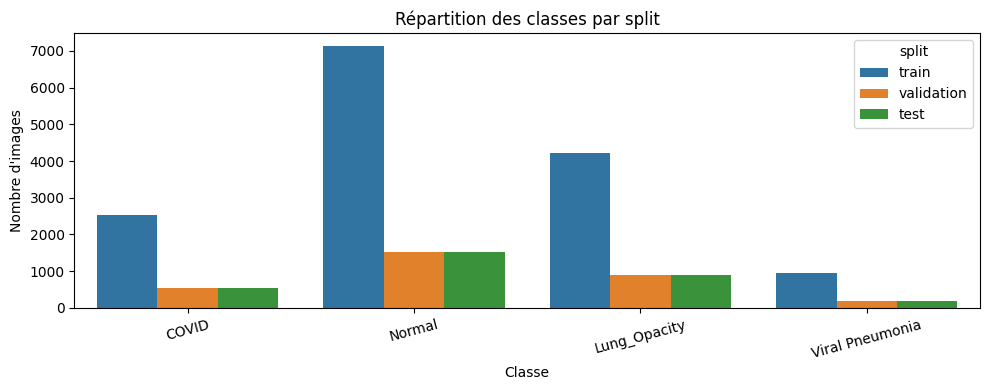

In [7]:

# =========================
# Répartition des classes par split
# =========================

def make_split_distribution(df, split_name):
    counts = df["label"].value_counts().reindex(CATEGORIES)
    return pd.DataFrame({
        "split": split_name,
        "class_name": CATEGORIES,
        "count": counts.values
    })

split_dist_df = pd.concat([
    make_split_distribution(train_df, "train"),
    make_split_distribution(val_df, "validation"),
    make_split_distribution(test_df, "test"),
], ignore_index=True)

display(split_dist_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=split_dist_df, x="class_name", y="count", hue="split")
plt.title("Répartition des classes par split")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

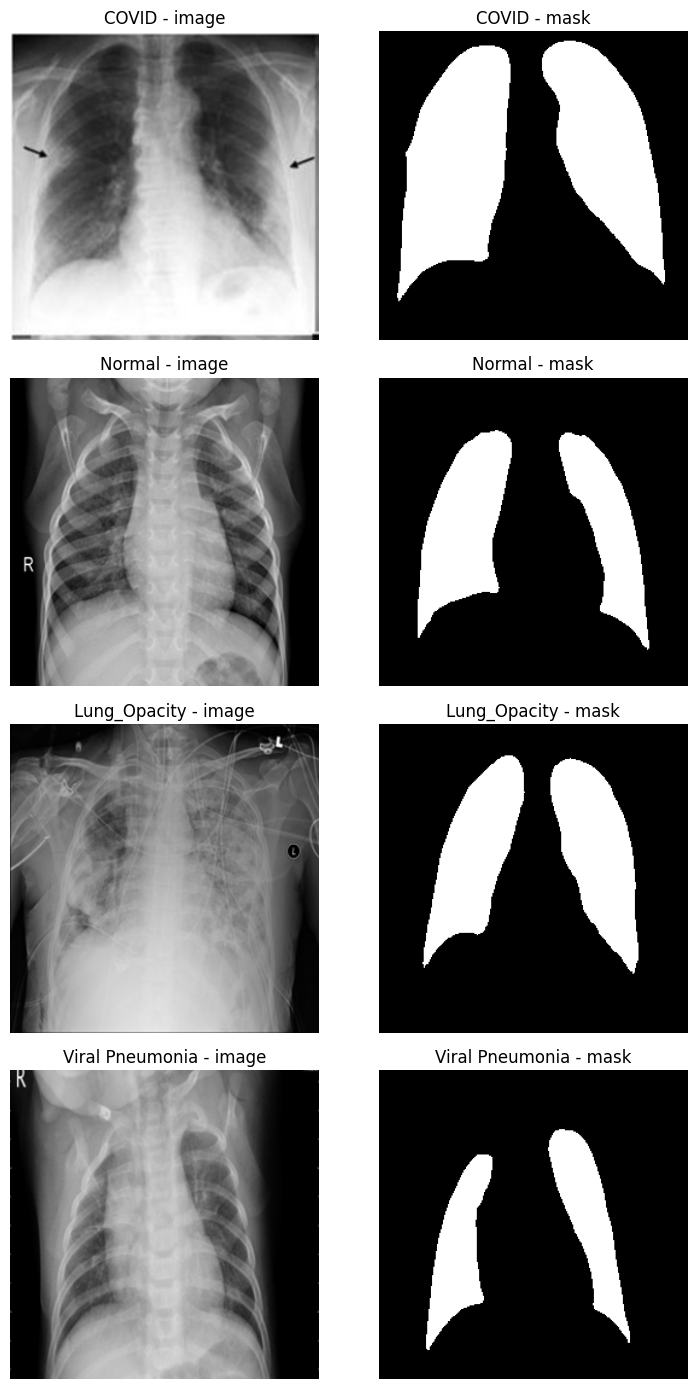

In [8]:

# =========================
# Vérification visuelle rapide
# =========================

fig, axes = plt.subplots(4, 2, figsize=(8, 14))

for i, category in enumerate(CATEGORIES):
    row = train_df[train_df["label"] == category].iloc[0]

    img = cv2.imread(row["image_path_local"], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(row["mask_path_local"], cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"{category} - image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"{category} - mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## Prétraitement `on-the-fly` pour EfficientNetB0

Ici, on garde l'esprit des notebooks précédents mais on adapte le format d'entrée au transfert learning :

- lecture en **grayscale**
- application du **masque** si activée
- **resize en 224x224**
- **CLAHE optionnel**
- conversion vers **RGB 3 canaux**
- appel à `preprocess_input` juste avant la base EfficientNet

In [9]:

# =========================
# Fonctions de prétraitement
# =========================

clahe = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP_LIMIT,
    tileGridSize=CLAHE_TILE_SIZE
)

def preprocess_image_for_efficientnet_numpy(image_path, mask_path):
    '''
    Prétraitement côté Python / OpenCV.

    Sortie :
    - image float32 de forme (224, 224, 3)
    - pixels gardés sur une échelle [0, 255]
      pour rester compatibles avec preprocess_input
    '''
    image_path = image_path.decode("utf-8")
    mask_path = mask_path.decode("utf-8")

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")

    mask = None
    if APPLY_MASK and Path(mask_path).exists():
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if APPLY_MASK and mask is not None:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.uint8)
        img = img * mask

    img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)

    if APPLY_CLAHE:
        img = clahe.apply(img)

    # On garde ici une image float32 sur l'échelle [0, 255]
    # Le prétraitement spécifique EfficientNet sera appliqué plus loin.
    img = img.astype(np.float32)

    # Conversion grayscale -> RGB 3 canaux
    img = np.stack([img, img, img], axis=-1)
    return img

def tf_preprocess(image_path, mask_path, label):
    image = tf.numpy_function(
        func=preprocess_image_for_efficientnet_numpy,
        inp=[image_path, mask_path],
        Tout=tf.float32
    )
    image.set_shape((TARGET_SIZE, TARGET_SIZE, N_CHANNELS))
    label = tf.cast(label, tf.int32)
    return image, label

def make_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path_local"].astype(str).values,
        df["mask_path_local"].astype(str).values,
        df["label_id"].values
    ))

    ds = ds.map(tf_preprocess, num_parallel_calls=AUTOTUNE)

    if CACHE_DATASET:
        ds = ds.cache()

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [10]:

# =========================
# Class weights
# =========================

classes = np.array(sorted(train_df["label_id"].unique()))
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_id"].values
)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights_values)}
print("Class weights :", class_weight_dict)

Class weights : {0: 1.4633544053733702, 1: 0.5191687692738997, 2: 0.8801687262357415, 3: 3.9317940552016983}


In [11]:

# =========================
# Pipelines tf.data
# =========================

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

for batch_images, batch_labels in train_ds.take(1):
    print("Shape images batch :", batch_images.shape)
    print("Shape labels batch :", batch_labels.shape)

Shape images batch : (8, 224, 224, 3)
Shape labels batch : (8,)


In [12]:

# =========================
# Bloc de data augmentation (optionnel)
# =========================

def build_augmentation_layer():
    return keras.Sequential(
        [
            layers.RandomRotation(AUG_ROTATION, seed=SEED),
            layers.RandomTranslation(AUG_TRANSLATION, AUG_TRANSLATION, seed=SEED),
            layers.RandomZoom(AUG_ZOOM, seed=SEED),
            layers.RandomContrast(AUG_CONTRAST, seed=SEED),
        ],
        name="data_augmentation"
    )

## Architecture du modèle de transfert learning

La structure retenue est :

- entrée image `224x224x3`
- data augmentation optionnelle
- `preprocess_input`
- base **EfficientNetB0** pré-entraînée ImageNet
- `GlobalAveragePooling2D`
- petite tête dense
- softmax 4 classes

In [13]:

# =========================
# Construction du modèle EfficientNetB0
# =========================

def build_efficientnet_transfer_model(input_shape=(TARGET_SIZE, TARGET_SIZE, N_CHANNELS), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape, name="input_image")

    x = inputs

    if USE_AUGMENTATION:
        x = build_augmentation_layer()(x)

    # Prétraitement spécifique EfficientNet
    x = layers.Lambda(preprocess_input, name="efficientnet_preprocess")(x)

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=None,
        input_shape=input_shape
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(0.30, name="head_dropout")(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.20, name="head_dropout_2")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="efficientnetb0_transfer_learning")
    return model, base_model

model, base_model = build_efficientnet_transfer_model()
model.summary()

Model: "efficientnetb0_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_preprocess         │ (None, 224, 224, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:

# =========================
# Nettoyage mémoire (optionnel)
# =========================

tf.keras.backend.clear_session()
gc.collect()

0

In [15]:

# =========================
# Compilation - phase 1 (tête seule)
# =========================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=HEAD_LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:

# =========================
# Callbacks
# =========================

checkpoint_path_phase1 = "best_efficientnetb0_phase1.keras"

callbacks_phase1 = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=checkpoint_path_phase1,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [17]:

# =========================
# Entraînement - phase 1
# =========================

fit_kwargs = dict(
    x=train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks_phase1,
    verbose=1
)

if USE_CLASS_WEIGHTS:
    fit_kwargs["class_weight"] = class_weight_dict

history_phase1 = model.fit(**fit_kwargs)

Epoch 1/8
1852/1852 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6352 - loss: 0.8302
Epoch 1: val_loss improved from None to 0.60198, saving model to best_efficientnetb0_phase1.keras

Epoch 1: finished saving model to best_efficientnetb0_phase1.keras
1852/1852 ━━━━━━━━━━━━━━━━━━━━ 164s 45ms/step - accuracy: 0.6890 - loss: 0.6832 - val_accuracy: 0.7537 - val_loss: 0.6020 - learning_rate: 0.0010
Epoch 2/8
1851/1852 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7212 - loss: 0.6040
Epoch 2: val_loss did not improve from 0.60198
1852/1852 ━━━━━━━━━━━━━━━━━━━━ 157s 42ms/step - accuracy: 0.7285 - loss: 0.5867 - val_accuracy: 0.7367 - val_loss: 0.6458 - learning_rate: 0.0010
Epoch 3/8
1850/1852 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7341 - loss: 0.5572
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 0.60198
1852/1852 ━━━━━━━━━━━━━━━━━━━━ 135s 39ms/step - accuracy: 0.7415 - loss: 0.5554 - val_accuracy: 0.6857 - va

In [20]:

# =========================
# Fine-tuning (phase 2)
# =========================
# On dégèle seulement les dernières couches de la base.
# Les BatchNormalization sont gardées gelées, ce qui est souvent plus stable.

history_phase2 = None

if DO_FINE_TUNING:
    base_model.trainable = True

    # On regèle toutes les BatchNorm pour garder des statistiques stables
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    # On laisse entraînables seulement les dernières couches demandées
    if UNFREEZE_LAST_N_LAYERS is not None and UNFREEZE_LAST_N_LAYERS > 0:
        for layer in base_model.layers[:-UNFREEZE_LAST_N_LAYERS]:
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    checkpoint_path_phase2 = "best_efficientnetb0_phase2.keras"

    callbacks_phase2 = [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path_phase2,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    fit_kwargs_phase2 = dict(
        x=train_ds,
        validation_data=val_ds,
        epochs=INITIAL_EPOCHS + FINE_TUNE_EPOCHS,
        initial_epoch=len(history_phase1.history["loss"]),
        callbacks=callbacks_phase2,
        verbose=1
    )

    if USE_CLASS_WEIGHTS:
        fit_kwargs_phase2["class_weight"] = class_weight_dict

    history_phase2 = model.fit(**fit_kwargs_phase2)

Epoch 9/16
1851/1852 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7828 - loss: 0.4690
Epoch 9: val_loss improved from None to 0.56721, saving model to best_efficientnetb0_phase2.keras

Epoch 9: finished saving model to best_efficientnetb0_phase2.keras
1852/1852 ━━━━━━━━━━━━━━━━━━━━ 165s 49ms/step - accuracy: 0.7866 - loss: 0.4677 - val_accuracy: 0.7720 - val_loss: 0.5672 - learning_rate: 1.0000e-05
Epoch 10/16
1852/1852 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7938 - loss: 0.4494
Epoch 10: val_loss improved from 0.56721 to 0.49890, saving model to best_efficientnetb0_phase2.keras

Epoch 10: finished saving model to best_efficientnetb0_phase2.keras
1852/1852 ━━━━━━━━━━━━━━━━━━━━ 157s 47ms/step - accuracy: 0.8014 - loss: 0.4388 - val_accuracy: 0.8047 - val_loss: 0.4989 - learning_rate: 1.0000e-05
Epoch 11/16
1851/1852 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8113 - loss: 0.4198
Epoch 11: val_loss did not improve from 0.49890
1852/1852 ━━━━━━━━━━━━━━━━━━━━ 161s 47ms/step 

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.688964,0.683212,0.753701,0.601979,0.0010
1,0.728518,0.586662,0.736693,0.645762,0.0010
2,0.741478,0.555353,0.685669,0.781077,0.0010
3,0.756666,0.523511,0.790236,0.547999,0.0005
4,0.760513,0.511913,0.765669,0.579442,0.0005


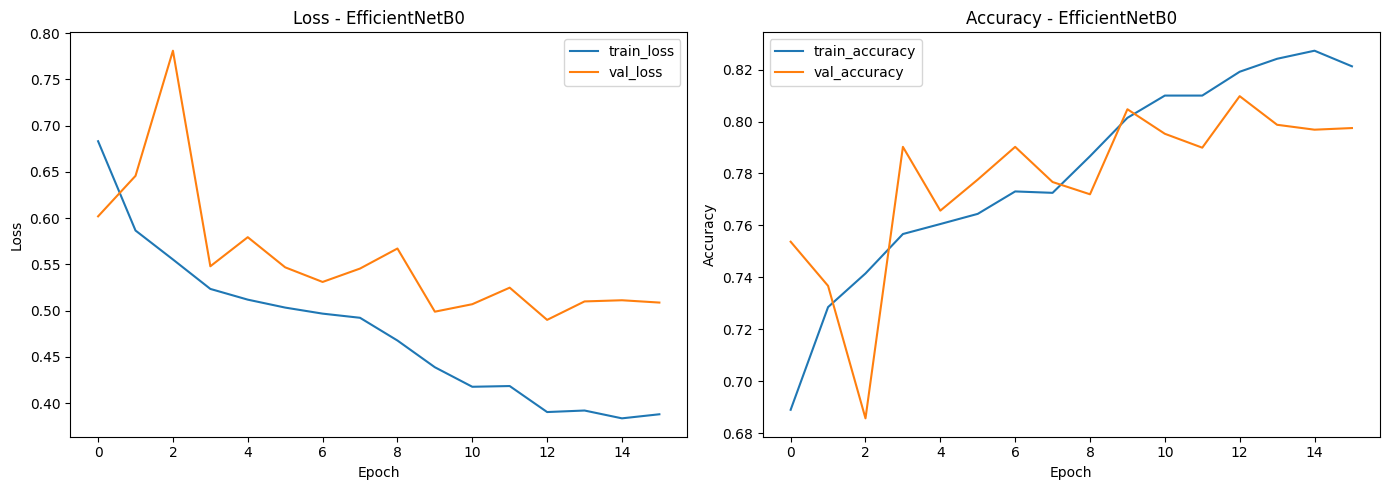

In [22]:

# =========================
# Fusion des historiques et courbes d'apprentissage
# =========================

def combine_histories(history1, history2=None):
    combined = {}
    for key, values in history1.history.items():
        combined[key] = list(values)

    if history2 is not None:
        for key, values in history2.history.items():
            combined[key] = combined.get(key, []) + list(values)

    return combined

full_history = combine_histories(history_phase1, history_phase2)

history_df = pd.DataFrame(full_history)
display(history_df.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(full_history["loss"], label="train_loss")
axes[0].plot(full_history["val_loss"], label="val_loss")
axes[0].set_title("Loss - EfficientNetB0")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(full_history["accuracy"], label="train_accuracy")
axes[1].plot(full_history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy - EfficientNetB0")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:

# =========================
# Évaluation sur le jeu de test
# =========================

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

y_proba = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_proba, axis=1)
y_test = test_df["label_id"].values

report = classification_report(
    y_test,
    y_pred,
    target_names=CATEGORIES,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

397/397 ━━━━━━━━━━━━━━━━━━━━ 33s 79ms/step - accuracy: 0.8123 - loss: 0.4769
Test loss     : 0.4769
Test accuracy : 0.8123
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step


,precision,recall,f1-score,support
COVID,0.620438,0.784133,0.692747,542.000000
Normal,0.893617,0.824068,0.857435,1529.000000
Lung_Opacity,0.877987,0.773836,0.822628,902.000000
Viral Pneumonia,0.687719,0.970297,0.804928,202.000000
accuracy,0.812283,0.812283,0.812283,0.812283
macro avg,0.769940,0.838083,0.794434,3175.000000
weighted avg,0.829443,0.812283,0.816092,3175.000000


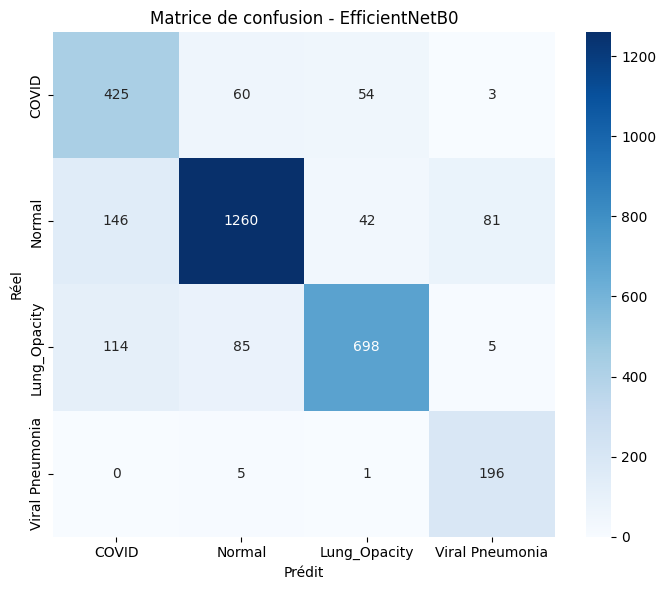

In [24]:

# =========================
# Matrice de confusion
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORIES,
    yticklabels=CATEGORIES
)
plt.title("Matrice de confusion - EfficientNetB0")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

In [25]:

# =========================
# Tableau de métriques par classe
# =========================

per_class_df = report_df.loc[CATEGORIES, ["precision", "recall", "f1-score", "support"]].copy()
per_class_df = per_class_df.reset_index().rename(columns={"index": "class_name"})
display(per_class_df)

,class_name,precision,recall,f1-score,support
0,COVID,0.620438,0.784133,0.692747,542.0
1,Normal,0.893617,0.824068,0.857435,1529.0
2,Lung_Opacity,0.877987,0.773836,0.822628,902.0
3,Viral Pneumonia,0.687719,0.970297,0.804928,202.0


In [26]:

# =========================
# Nettoyage mémoire (optionnel)
# =========================

tf.keras.backend.clear_session()
gc.collect()

0